# 02 - Model Comparison

Comparación de diferentes arquitecturas de transfer learning: EfficientNetB0, ResNet50, y Xception.

## 1. Importar librerías y cargar datos

In [7]:
import sys
import os
# sys.path.append(os.path.join(os.getcwd(), '../../src'))
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(PROJECT_ROOT)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from src.utils import (
    load_data_npz,
    build_model,
    build_efficient_net_b0,
    build_resnet50,
    build_xception,
    train_model,
    evaluate_model,
    compare_models_roc,
    summary_table,
    DATA_NPZ_PATH,
    MODEL_PATH
)

## 2. Cargar datos

In [ ]:
X_train, X_test, y_train, y_test = load_data_npz(DATA_NPZ_PATH)
print(f'Datos cargados:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test:  {X_test.shape}')

Datos cargados:
  X_train: (878, 224, 224, 3)
  X_test:  (177, 224, 224, 3)


## 3. Preparar datos para Xception (299x299)

In [ ]:
X_train_xception = tf.image.resize(X_train, [299, 299]).numpy()
X_test_xception  = tf.image.resize(X_test,  [299, 299]).numpy()

print(f'Datos redimensionados para Xception:')
print(f'  X_train_xception: {X_train_xception.shape}')
print(f'X  X_test_xception:  {X_test_xception.shape}')

Datos redimensionados para Xception:
  X_train_xception: (878, 299, 299, 3)
  X_test_xception:  (177, 299, 299, 3)


## 4. Entrenar modelos

In [4]:
# Diccionario con modelos a probar
BACKBONES = {
    'EfficientNetB0': (build_efficient_net_b0, X_train, X_test),
    'ResNet50': (build_resnet50, X_train, X_test),
    'Xception': (build_xception, X_train_xception, X_test_xception)
}

results = []

for name, (builder_fn, X_tr, X_te) in BACKBONES.items():
    print(f'\n>>> Entrenando {name}...')
    model = builder_fn()
    history = train_model(model, X_tr, y_train, epochs=30, batch_size=32)
    result = evaluate_model(model, X_te, y_test, model_name=name)
    results.append(result)


>>> Entrenando EfficientNetB0...
Epoch 1/30
24/24 [==============================] - 36s 1s/step - loss: 0.7367 - accuracy: 0.5255 - val_loss: 0.7138 - val_accuracy: 0.3106 - lr: 1.0000e-04
Epoch 2/30
24/24 [==============================] - 26s 1s/step - loss: 0.7248 - accuracy: 0.5684 - val_loss: 0.7235 - val_accuracy: 0.3106 - lr: 1.0000e-04
Epoch 3/30
24/24 [==============================] - 25s 1s/step - loss: 0.7181 - accuracy: 0.5885 - val_loss: 0.7120 - val_accuracy: 0.3106 - lr: 1.0000e-04
Epoch 4/30
24/24 [==============================] - 24s 1s/step - loss: 0.6834 - accuracy: 0.6072 - val_loss: 0.7037 - val_accuracy: 0.3106 - lr: 1.0000e-04
Epoch 5/30
24/24 [==============================] - 25s 1s/step - loss: 0.6995 - accuracy: 0.5912 - val_loss: 0.6917 - val_accuracy: 0.6894 - lr: 1.0000e-04
Epoch 6/30
24/24 [==============================] - 25s 1s/step - loss: 0.6938 - accuracy: 0.5845 - val_loss: 0.6952 - val_accuracy: 0.3333 - lr: 1.0000e-04
Epoch 7/30
24/24 [======

c:\Users\NitroPC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NitroPC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NitroPC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p


  EfficientNetB0
Accuracy:  0.5198
AUC-ROC:   0.5335

Reporte de clasificación:
              precision    recall  f1-score   support

    sin_cara       0.52      1.00      0.68        92
        cara       0.00      0.00      0.00        85

    accuracy                           0.52       177
   macro avg       0.26      0.50      0.34       177
weighted avg       0.27      0.52      0.36       177


>>> Entrenando ResNet50...
Epoch 1/30
24/24 [==============================] - 51s 2s/step - loss: 0.6784 - accuracy: 0.5938 - val_loss: 0.6193 - val_accuracy: 0.6894 - lr: 1.0000e-04
Epoch 2/30
24/24 [==============================] - 46s 2s/step - loss: 0.6492 - accuracy: 0.6113 - val_loss: 0.6159 - val_accuracy: 0.6894 - lr: 1.0000e-04
Epoch 3/30
24/24 [==============================] - 48s 2s/step - loss: 0.6312 - accuracy: 0.6381 - val_loss: 0.6153 - val_accuracy: 0.6894 - lr: 1.0000e-04
Epoch 4/30
24/24 [==============================] - 48s 2s/step - loss: 0.5926 - accuracy: 0.

## 5. Comparar modelos


RESUMEN DE MODELOS
        Modelo Accuracy AUC-ROC
      Xception   0.8475  0.9312
      ResNet50   0.6328  0.7178
EfficientNetB0   0.5198  0.5335


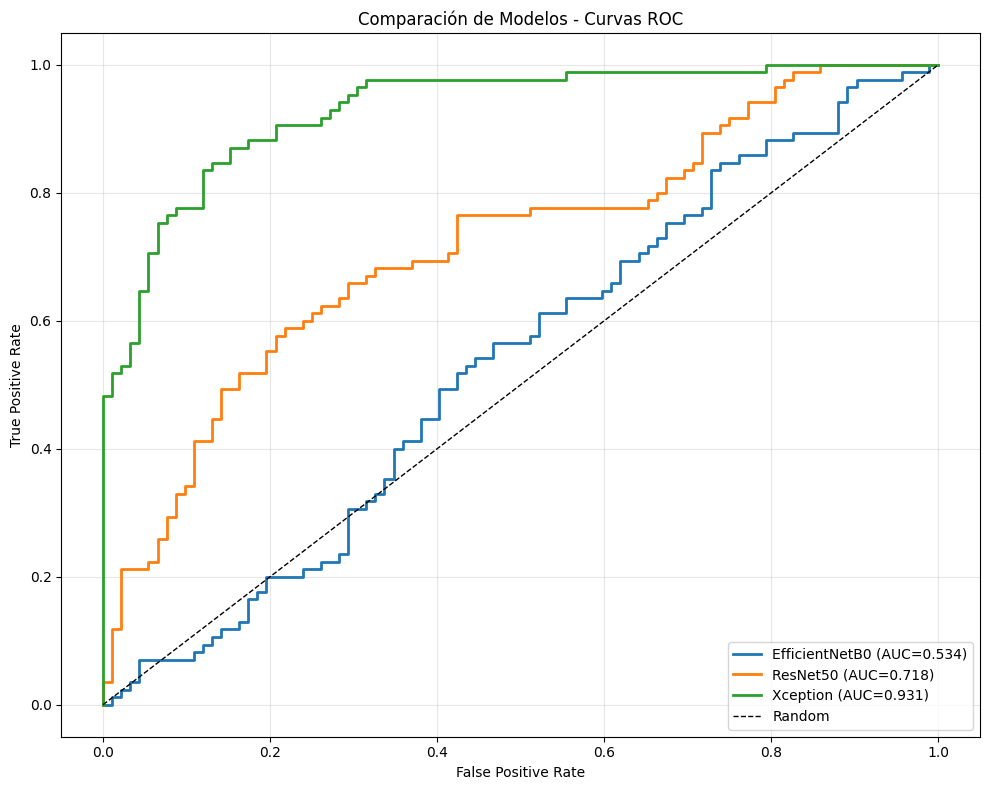

In [5]:
# Tabla resumen
summary_table(results)

# Curvas ROC
compare_models_roc(results, y_test)

## 6. Seleccionar mejor modelo

In [ ]:
best_result = max(results, key=lambda r: r['auc'])
print(f'\n✓ Mejor modelo: {best_result["model_name"]}')
print(f'  AUC-ROC: {best_result["auc"]:.4f}')
print(f'  Accuracy: {best_result['accuracy']:.4f}')


✓ Mejor modelo: Xception
  AUC-ROC: 0.9312
  Accuracy: 0.8475


## 7. Guardar modelo

In [14]:
model.save(f'{MODEL_PATH}{best_result["model_name"]}.keras')
print(f'Modelo guardado en {MODEL_PATH}{best_result["model_name"]}.keras')

Modelo guardado en c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\src/model/Xception.keras
